In [2]:
!pip install matplotlib scikit-learn pandas numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 24.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 33.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 29.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 27.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 38.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [matplotlib]1 [matplotlib]n]


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [7]:

diabetes = load_diabetes()

# put the data into a dataframe so its easier to read
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

print("Shape of dataset:", df.shape)
print("\nFeature names:", diabetes.feature_names)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (442, 11)

Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

First 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [9]:

df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [10]:

print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


In [11]:

X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (353, 10)
Testing set size: (89, 10)


In [12]:

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
r2_baseline = r2_score(y_test, y_pred)

print("Baseline R2 score with all 10 features:", round(r2_baseline, 4))


Baseline R2 score with all 10 features: 0.4526


In [13]:

feature_names = list(diabetes.feature_names)
r2_scores = []
coef_table = {}

for n in range(1, 11):
    rfe = RFE(estimator=LinearRegression(), n_features_to_select=n)
    rfe.fit(X_train, y_train)

    model = LinearRegression()
    model.fit(X_train[:, rfe.support_], y_train)

    y_pred_rfe = model.predict(X_test[:, rfe.support_])
    r2 = r2_score(y_test, y_pred_rfe)
    r2_scores.append(r2)

    # save coefficients, set 0 for features that were eliminated
    coefs = {}
    coef_idx = 0
    for i, fname in enumerate(feature_names):
        if rfe.support_[i]:
            coefs[fname] = round(model.coef_[coef_idx], 2)
            coef_idx += 1
        else:
            coefs[fname] = 0
    coef_table[n] = coefs

print("R2 score at each step:")
for n, r2 in zip(range(1, 11), r2_scores):
    print(f"  {n} feature(s): {round(r2, 4)}")

R2 score at each step:
  1 feature(s): 0.2334
  2 feature(s): 0.4523
  3 feature(s): 0.4451
  4 feature(s): 0.4464
  5 feature(s): 0.4382
  6 feature(s): 0.4628
  7 feature(s): 0.4583
  8 feature(s): 0.4559
  9 feature(s): 0.4587
  10 feature(s): 0.4526


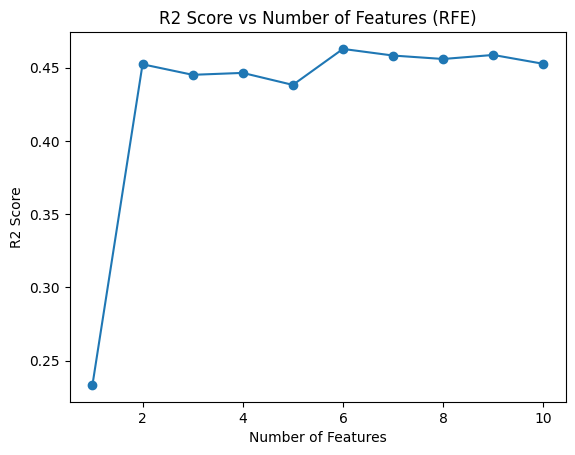

In [28]:
plt.plot(range(1, 11), r2_scores, marker='o')
plt.xlabel("Number of Features")
plt.ylabel("R2 Score")
plt.title("R2 Score vs Number of Features (RFE)")
plt.show()

In [29]:

optimal_n = 6
print("Based on the plot, the optimal number of features is 6.")
print(f"R2 at optimal n=6: {round(r2_scores[optimal_n - 1], 4)}")


Based on the plot, the optimal number of features is 6.
R2 at optimal n=6: 0.4628


In [16]:

coef_df = pd.DataFrame(coef_table).T
coef_df.index.name = "n_features"
print("Coefficients at each RFE iteration (0 means feature was removed):")
coef_df

Coefficients at each RFE iteration (0 means feature was removed):


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
n_features,,,,,,,,,,
1,0.0,0.00,998.58,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0.0,0.00,732.11,0.00,0.00,0.00,0.00,0.00,562.23,0.00
3,0.0,0.00,737.69,0.00,-228.34,0.00,0.00,0.00,680.22,0.00
4,0.0,0.00,691.46,0.00,-592.98,362.95,0.00,0.00,783.17,0.00
5,0.0,0.00,597.89,306.65,-655.56,409.62,0.00,0.00,728.64,0.00
6,0.0,-215.27,557.31,350.18,-851.52,591.09,0.00,0.00,803.12,0.00
7,0.0,-235.36,551.87,362.36,-660.64,343.35,0.00,185.14,664.77,0.00
8,0.0,-233.75,550.74,363.79,-947.82,541.59,172.25,277.74,761.92,0.00
9,0.0,-236.65,542.80,354.21,-936.35,528.80,167.80,270.40,744.45,53.35


In [17]:

rfe_full = RFE(estimator=LinearRegression(), n_features_to_select=1)
rfe_full.fit(X_train, y_train)

ranking_df = pd.DataFrame({
    'Feature': feature_names,
    'Rank': rfe_full.ranking_
}).sort_values('Rank')

print("Feature ranking (1 = most important, 10 = least important):")
print(ranking_df.to_string(index=False))

Feature ranking (1 = most important, 10 = least important):
Feature  Rank
    bmi     1
     s5     2
     s1     3
     s2     4
     bp     5
    sex     6
     s4     7
     s3     8
     s6     9
    age    10


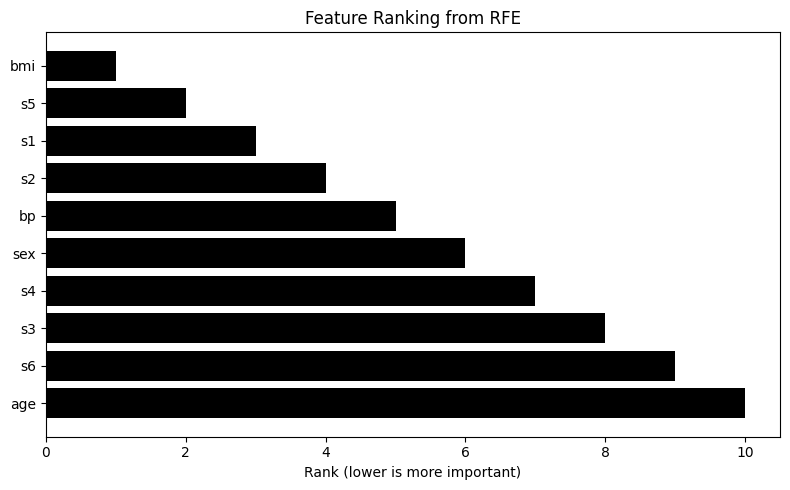

In [37]:

plt.figure(figsize=(8, 5))
plt.barh(ranking_df['Feature'], ranking_df['Rank'], color='black')
plt.xlabel("Rank (lower is more important)")
plt.title("Feature Ranking from RFE")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:

print("Initial model coefficients using all 10 features:")
for fname, coef in zip(feature_names, lr.coef_):
    print(f"  {fname}: {round(coef, 2)}")

rfe_optimal = RFE(estimator=LinearRegression(), n_features_to_select=optimal_n)
rfe_optimal.fit(X_train, y_train)

selected = [feature_names[i] for i in range(10) if rfe_optimal.support_[i]]
print(f"\nSelected features with optimal n={optimal_n}:", selected)

Initial model coefficients using all 10 features:
  age: 37.9
  sex: -241.96
  bmi: 542.43
  bp: 347.7
  s1: -931.49
  s2: 518.06
  s3: 163.42
  s4: 275.32
  s5: 736.2
  s6: 48.67

Selected features with optimal n=6: ['sex', 'bmi', 'bp', 's1', 's2', 's5']


In [20]:

print("Summary")
print(f"Baseline R2 with all 10 features : {round(r2_baseline, 4)}")
print(f"Optimal number of features        : {optimal_n}")
print(f"R2 with optimal features          : {round(r2_scores[optimal_n - 1], 4)}")
print(f"Selected features                 : {selected}")

Summary
Baseline R2 with all 10 features : 0.4526
Optimal number of features        : 6
R2 with optimal features          : 0.4628
Selected features                 : ['sex', 'bmi', 'bp', 's1', 's2', 's5']


**Q1. What did I learn about feature selection using RFE?**

I learned that not all features actually help the model predict better.
RFE works by removing the least useful feature one at a time, and I could
see from the R2 scores that using all 10 features doesnt always give the
best result. With just 6 features the model actually did a little better
than using all 10. So feature selection is actually pretty important and
can make the model simpler and more accurate at the same time.

**Q2. How does RFE compare to LASSO?**

LASSO and RFE both help pick useful features but they work differently.
LASSO adds a penalty to the model during training so it automatically
pushes unimportant feature coefficients down to zero. RFE does it more
manually, it trains the model, removes the weakest feature, then repeats.
I think RFE is easier to understand because you can actually see which
features got removed step by step. LASSO is faster but its harder to
see whats happening inside.

**Q3. What insights can you draw about the dataset from the selected features?**

The 6 features that got selected are bmi, bp, s1, s2, s5, and sex.
I think bmi and bp make a lot of sense because high BMI and high blood
pressure are things doctors always talk about with diabetes. s5 is
related to triglycerides which is also connected to blood sugar levels.
One thing that surprised me was that age got ranked last (rank 10),
since I expected age to be more important for predicting diabetes.
Maybe in this dataset the blood-related measurements are just stronger
predictors than age.